# TCCT S79A — Minimal Blind-Failure Mechanism Audit

这是独立轻量审计：**不载入 S59–S78 Notebook，不重跑历史测试，不训练、不搜索、不改冻结模型。**

只运行两组必要数据：16 个原始 S79 blind cases，以及 48 个小规模 motif 对照 cases。按顺序运行下面 4 个代码单元；最后一格给出 `RootCause`、完整性锁和下一阶段建议。


Dataset[{<|Stage -> S79A, Name -> MinimalBlindFailureMechanismAudit, 
 
>     StandaloneMinimalKernel -> True, HistoricalTestsIncluded -> False, 
 
>     TrainingRun -> False, CandidateSearchRun -> False, PolicyEditApplied -> False, 
 
>     RetuningApplied -> False, ExpectedS79BlindResultHash -> 
 
>      b1ebf089e43121a61d4181139d4ba0a8970dc646a7a41425f861cff2e1f8461d, 
 
>     FrozenModelHash -> 
 
>      d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4, 
 
>     TopologySpecHash -> 
 
>      b108aa7f2c59c395056fb9124e7d5d9074e39e5e124d0d98011800433e0dd95b, 
 
>     TopologyImplementationHash -> 
 
>      f27d1ce683317d35a5e9da01536d95c706065810c27462e336cdb76f4a2dab52, 
 
>     MinimalKernelHash -> 
 
>      ec291466f20922dc4b2b879853cd3879c37151fb7e96c34eff45dcb185fe7f34, 
 
>     PreflightPassed -> True|>}, TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, 
 
>      StandaloneMinimalKernel, HistoricalTestsIncluded, TrainingRun, 
 
>      CandidateSearchRun, PolicyEditApplied, RetuningApplied, 
 
>      ExpectedS79BlindResultHash, FrozenModelHash, TopologySpecHash, 
 
>      TopologyImplementationHash, MinimalKernelHash, PreflightPassed}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean]}], 1], <||>]
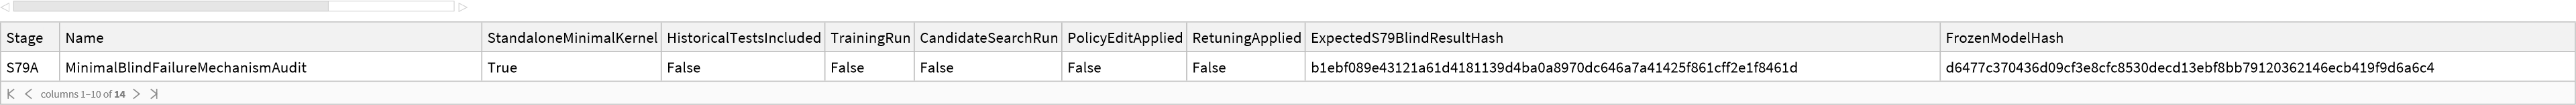

In [5]:
ClearAll["Global`*"];
$HistoryLength=0;

expectedFrozenModelHash79A=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedTopologySpecHash79A=
"b108aa7f2c59c395056fb9124e7d5d9074e39e5e124d0d98011800433e0dd95b";
expectedTopologyImplementationHash79A=
"f27d1ce683317d35a5e9da01536d95c706065810c27462e336cdb76f4a2dab52";
expectedS79BlindResultHash79A=
"b1ebf089e43121a61d4181139d4ba0a8970dc646a7a41425f861cff2e1f8461d";

frozen75D=<|
"Stage"->"S75D",
"Name"->"ValidatedPolicyCompletion",
"Representation"->
"PairedRadius2Radius3WithParentChildCardinality",
"Params"->{-1,0,-1,-1,-1,0,1,-1},
"K"->5,
"TrainingPolicy"->{{3,1},{3,3},{4,3}},
"Policy"->{
{1,3},{2,2},{3,1},{3,2},{3,3},{4,3}
},
"AddedContinueCodes"->{{1,3},{2,2},{3,2}},
"PolicyCompletionUsesValidationLabels"->True,
"FrozenBeforeS76"->True
|>;

P59[a_,b_,n_Integer,s_Integer]:=If[
n<=0,
{DirectedEdge[a,b]},
DirectedEdge@@@Partition[
Join[{a},Range[s,s+n-1],{b}],
2,
1
]
];

A59[t_,fan_Integer,s_Integer]:=Module[{p1,p2,ls},
p1=s+1;
p2=s+2;
ls=Range[s+3,s+2+fan];
Join[
{
DirectedEdge[p2,p1],
DirectedEdge[p1,t]
},
Table[
DirectedEdge[ls[[i]],p2],
{i,Length[ls]}
]
]
];

T59[d_Integer,r_String,a_Integer,seed_Integer]:=Module[
{
bb,K,c,v,q,e,f={},ib,m,safe,u,dum,r1,r2,wrong,
main,perm,anc,i
},
bb=1000000000 seed;
K=bb+1;
c=Table[bb+100+i,{i,4}];
v=Table[bb+200+i,{i,4}];
q=Table[bb+300+i,{i,4}];
e=Flatten[
Table[
{
DirectedEdge[K,c[[i]]],
DirectedEdge[c[[i]],v[[i]]]
},
{i,4}
],
1
];
Do[
ib=bb+20000000 i;
m=ib+1;
safe=ib+2;
u=ib+3;
dum=ib+4;
r1=ib+10;
r2=ib+20;
wrong=c[[1+Mod[i,4]]];
main=Join[
P59[q[[i]],r1,d,ib+1000000],
P59[q[[i]],r2,d,ib+2000000],
{
DirectedEdge[r1,m],
DirectedEdge[r2,m]
},
P59[q[[i]],safe,d+1,ib+3000000]
];
perm=If[
r==="Continue",
{
DirectedEdge[m,c[[i]]],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
},
{
DirectedEdge[m,wrong],
DirectedEdge[safe,c[[i]]],
DirectedEdge[u,dum]
}
];
anc=Join[
A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]
];
e=Join[e,main,perm,anc];
AppendTo[f,m],
{i,4}
];
{{Union[e],q,K,v,c,f},a}
];

Case59[d_Integer,a_Integer,r_String]:=
T59[d,r,a,59000000+100 d+a];

rw60={-9,6,-2,-2,4,2,-2,6,0};

Pack60[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,v,pos,gi,go,pa,ch,id,od,
pin,pout,cin,cout},
e=x[[1]];
v=Union@Join[
Flatten[List@@@e],
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
pos=AssociationThread[v,Range[Length[v]]];
gi=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{w,u}],
First->Last
];
go=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{u,w}],
First->Last
];
pa=(Lookup[pos,Lookup[gi,#,{}]]&)/@v;
ch=(Lookup[pos,Lookup[go,#,{}]]&)/@v;
id=Length/@pa;
od=Length/@ch;
pin=(Total[id[[#]]]&)/@pa;
pout=(Total[od[[#]]]&)/@pa;
cin=(Total[id[[#]]]&)/@ch;
cout=(Total[od[[#]]]&)/@ch;
{
pa,id,od,
Lookup[pos,x[[2,a]]],
Lookup[pos,x[[5]]],
a,
Length[v],
pin,pout,cin,cout,v
}
];

SigLevels61[c_List,rmax_Integer]:=Module[
{p,pa,id,od,n,ch,cur,nxt,levs,j,k,u},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
n=p[[7]];
ch=Table[{},n];
Do[
Do[
If[u>0,ch[[u]]=Append[ch[[u]],j]],
{u,pa[[j]]}
],
{j,n}
];
cur=AssociationThread[
Range[n],
MapThread[List,{id,od}]
];
levs={cur};
Do[
nxt=AssociationThread[
Range[n],
Table[
{
Lookup[cur,j],
Sort[Lookup[cur,pa[[j]]]],
Sort[Lookup[cur,ch[[j]]]]
},
{j,n}
]
];
AppendTo[levs,nxt];
cur=nxt,
{k,rmax}
];
levs
];

PropagationSafetyCap78[c_List]:=Module[{n},
n=Pack60[c][[7]];
Max[64,2 n+8]
];

RejectTrace78[c_List]:=Module[
{
p,pa,id,od,q,n,pin,pout,cin,cout,h,z,h2,nz,j,k,
aps,ap,pz,o,zv,rf,rd,dd,pg,allow,active=0,
rej={},rounds=0,terminatedNaturally=False,safetyCap
},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
q=p[[4]];
n=p[[7]];
pin=p[[8]];
pout=p[[9]];
cin=p[[10]];
cout=p[[11]];
safetyCap=Max[64,2 n+8];
h=ConstantArray[0,n];
z=ConstantArray[0,n];
h[[q]]=1;
For[
k=1,
k<=safetyCap,
k++,
rounds=k;
h2=ConstantArray[0,n];
nz=ConstantArray[0,n];
active=0;
Do[
aps=Select[
pa[[j]],
Function[u,u>0&&h[[u]]==1]
];
ap=Length[aps];
If[
ap>0,
pz=Max[z[[aps]]];
o=Boole[ap>1];
zv={0,1,2,1,3,1,3,1}[[1+2 pz+o]];
nz[[j]]=zv;
rf={
1,
Boole[zv>0],
zv,
Sign[pin[[j]]-id[[j]]],
Sign[pout[[j]]-id[[j]]],
Sign[cin[[j]]-id[[j]]],
Sign[cout[[j]]-od[[j]]],
Sign[id[[j]]-od[[j]]],
Sign[pout[[j]]-cin[[j]]]
};
rd=rw60.rf;
dd=1-cin[[j]]+2 cout[[j]];
pg=od[[j]]+2 Boole[zv>0]-zv;
If[rd>0&&dd<=0,AppendTo[rej,{k,j}]];
allow=If[rd>0,dd>0,pg>0];
If[
TrueQ[allow],
h2[[j]]=1;
active++
]
],
{j,n}
];
h=h2;
z=nz;
If[
active==0,
terminatedNaturally=True;
Break[]
]
];
<|
"Rejects"->rej,
"RoundsExecuted"->rounds,
"TerminatedNaturally"->terminatedNaturally,
"SafetyCap"->safetyCap,
"HitSafetyCap"->And[
!TrueQ[terminatedNaturally],
SameQ[rounds,safetyCap]
],
"ActiveAfterLastRound"->active,
"PackedNodeCount"->n
|>
];

DecisionStatePairsFromRejects78[c_List,rej_List]:=Module[
{levels,nodes},
If[Length[rej]==0,Return[{}]];
levels=SigLevels61[c,3];
nodes=rej[[All,2]];
DeleteDuplicates[
Map[
Function[node,
{
Lookup[levels[[3]],node],
Lookup[levels[[4]],node]
}
],
nodes
]
]
];

EncodeRows75[data_List,p_List,k_Integer]:=Module[{rec},
rec[s_]:=rec[s]=If[
MatchQ[s,{_Integer,_Integer}],
1+Mod[s[[1]]+2 s[[2]],k],
Module[
{z,ps,cs,parentSum,childSum,parentSquare,childSquare},
z=rec[s[[1]]];
ps=rec/@s[[2]];
cs=rec/@s[[3]];
parentSum=Total[ps-1];
childSum=Total[cs-1];
parentSquare=Total[(ps-1)^2];
childSquare=Total[(cs-1)^2];
1+Mod[
p[[1]]+
p[[2]](z-1)+
p[[3]]parentSum+
p[[4]]childSum+
p[[5]]parentSquare+
p[[6]]childSquare+
p[[7]]Length[ps]+
p[[8]]Length[cs],
k
]
]
];
Map[
Function[row,
Join[
KeyTake[row,{"Grammar","Depth","Answer","Target"}],
<|
"Codes"->DeleteDuplicates[
Map[
Function[pair,{rec[pair[[1]]],rec[pair[[2]]]}],
row["StatePairs"]
]
]
|>
]
],
data
]
];

DiamondIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,rm,
add,s1,s2,g,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
rm=DirectedEdge@@@incs;
add={};
Do[
s1=next;
s2=next+1;
g=next+2;
next=next+3;
add=Join[
add,
{
DirectedEdge[incs[[j,1]],s1],
DirectedEdge[incs[[j,1]],s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,rm],add],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

DoubleDiamondIn79[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g1,t1,t2,g2,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g1=next+2;
t1=next+3;
t2=next+4;
g2=next+5;
next=next+6;
added=Join[
added,
{
DirectedEdge[parent,s1],
DirectedEdge[parent,s2],
DirectedEdge[s1,g1],
DirectedEdge[s2,g1],
DirectedEdge[g1,t1],
DirectedEdge[g1,t2],
DirectedEdge[t1,g2],
DirectedEdge[t2,g2],
DirectedEdge[g2,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,removed],added],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

Case79[
depth_Integer,
answer_Integer,
target_String
]:=DoubleDiamondIn79[
Case59[depth,answer,target]
];

topologySpec79=<|
"Topology"->"DoubleDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->"TwoSerialPrivateDiamonds",
"CrossParentSharing"->False,
"DiamondsPerOriginalIncomingEdge"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->6,
"ReplacementEdgesPerOriginalIncomingEdge"->9,
"EdgeDeltaPerOriginalIncomingEdge"->8,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"TopologyUsedInS59ThroughS78"->False
|>;

topologySpecHash79=Hash[
Normal[topologySpec79],
"SHA256",
"HexString"
];

topologyImplementationHash79=Hash[
{DownValues[DoubleDiamondIn79],DownValues[Case79]},
"SHA256",
"HexString"
];

modelHash79A=Hash[
Normal[frozen75D],
"SHA256",
"HexString"
];

minimalKernelHash79A=Hash[
{
DownValues[P59],
DownValues[A59],
DownValues[T59],
DownValues[Case59],
OwnValues[rw60],
DownValues[Pack60],
DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],
DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],
DownValues[EncodeRows75],
DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],
DownValues[Case79]
},
"SHA256",
"HexString"
];

preflightPass79A=And[
SameQ[modelHash79A,expectedFrozenModelHash79A],
SameQ[topologySpecHash79,expectedTopologySpecHash79A],
SameQ[
topologyImplementationHash79,
expectedTopologyImplementationHash79A
]
];

preflight79A=<|
"Stage"->"S79A",
"Name"->"MinimalBlindFailureMechanismAudit",
"StandaloneMinimalKernel"->True,
"HistoricalTestsIncluded"->False,
"TrainingRun"->False,
"CandidateSearchRun"->False,
"PolicyEditApplied"->False,
"RetuningApplied"->False,
"ExpectedS79BlindResultHash"->
expectedS79BlindResultHash79A,
"FrozenModelHash"->modelHash79A,
"TopologySpecHash"->topologySpecHash79,
"TopologyImplementationHash"->
topologyImplementationHash79,
"MinimalKernelHash"->minimalKernelHash79A,
"PreflightPassed"->preflightPass79A
|>;

If[
!TrueQ[preflightPass79A],
Print[Dataset[{preflight79A}]];
Print["S79A aborted: minimal kernel does not reproduce frozen S79 definitions."];
Abort[]
];

Dataset[{preflight79A}]


In [35]:
ClearAll[
PrepareAuditRow79A,
PredictCodes79A,
CodeSetByTarget79A,
RawHashSetByTarget79A
];

PredictCodes79A[codes_List]:=If[
AnyTrue[codes,MemberQ[frozen75D["Policy"],#]&],
"Continue",
"Stop"
];

PrepareAuditRow79A[
grammar_String,
depth_Integer,
answer_Integer,
target_String,
case_List
]:=Module[
{traceSeconds,trace,pairs,encoded,codes,prediction},
{traceSeconds,trace}=AbsoluteTiming[RejectTrace78[case]];
pairs=DecisionStatePairsFromRejects78[
case,
trace["Rejects"]
];
encoded=First@EncodeRows75[
{
<|
"Grammar"->grammar,
"Depth"->depth,
"Answer"->answer,
"Target"->target,
"StatePairs"->pairs
|>
},
frozen75D["Params"],
frozen75D["K"]
];
codes=encoded["Codes"];
prediction=PredictCodes79A[codes];
<|
"Grammar"->grammar,
"Depth"->depth,
"Answer"->answer,
"Target"->target,
"TraceSeconds"->traceSeconds,
"RoundsExecuted"->trace["RoundsExecuted"],
"TerminatedNaturally"->trace["TerminatedNaturally"],
"HitSafetyCap"->trace["HitSafetyCap"],
"StatePairs"->pairs,
"StatePairCount"->Length[pairs],
"RawStatePairHash"->Hash[
pairs,
"SHA256",
"HexString"
],
"Codes"->codes,
"Prediction"->prediction,
"Correct"->SameQ[prediction,target]
|>
];

CodeSetByTarget79A[rows_List,target_String]:=
Union@@Lookup[
Select[rows,SameQ[#["Target"],target]&],
"Codes"
];

RawHashSetByTarget79A[rows_List,target_String]:=
DeleteDuplicates@Lookup[
Select[rows,SameQ[#["Target"],target]&],
"RawStatePairHash"
];

s79ReproductionRows79A=Flatten[
Table[
PrepareAuditRow79A[
"DoubleDiamondIn",
depth,
answer,
target,
Case79[depth,answer,target]
],
{depth,{191,255}},
{answer,Range[4]},
{target,{"Continue","Stop"}}
],
2
];

s79ContinueCodes79A=CodeSetByTarget79A[
s79ReproductionRows79A,
"Continue"
];

s79StopCodes79A=CodeSetByTarget79A[
s79ReproductionRows79A,
"Stop"
];

s79ReproductionSummary79A=<|
"Cases"->Length[s79ReproductionRows79A],
"Passed"->Count[
s79ReproductionRows79A,
row_/;TrueQ[row["Correct"]]
],
"NonEmptyStatePairs"->Count[
s79ReproductionRows79A,
row_/;row["StatePairCount"]>0
],
"TerminatedNaturally"->Count[
s79ReproductionRows79A,
row_/;TrueQ[row["TerminatedNaturally"]]
],
"HitSafetyCap"->Count[
s79ReproductionRows79A,
row_/;TrueQ[row["HitSafetyCap"]]
],
"ContinueCodes"->s79ContinueCodes79A,
"StopCodes"->s79StopCodes79A,
"ContinuePredictionCounts"->Counts@Lookup[
Select[
s79ReproductionRows79A,
SameQ[#["Target"],"Continue"]&
],
"Prediction"
],
"StopPredictionCounts"->Counts@Lookup[
Select[
s79ReproductionRows79A,
SameQ[#["Target"],"Stop"]&
],
"Prediction"
],
"TotalTraceSeconds"->Total[
Lookup[s79ReproductionRows79A,"TraceSeconds"]
]
|>;

s79FailureReproduced79A=And[
SameQ[s79ReproductionSummary79A["Cases"],16],
SameQ[s79ReproductionSummary79A["Passed"],0],
SameQ[
s79ReproductionSummary79A["NonEmptyStatePairs"],
16
],
SameQ[
s79ReproductionSummary79A["TerminatedNaturally"],
16
],
SameQ[s79ReproductionSummary79A["HitSafetyCap"],0],
SameQ[s79ContinueCodes79A,{{2,3}}],
SameQ[s79StopCodes79A,{{2,2}}]
];

If[
!TrueQ[s79FailureReproduced79A],
Print[Dataset[{s79ReproductionSummary79A}]];
Print["S79A aborted: standalone kernel did not reproduce the S79 failure fingerprint."];
Abort[]
];

Dataset[{s79ReproductionSummary79A}]


Dataset[{<|Cases -> 16, Passed -> 0, NonEmptyStatePairs -> 16, 
 
>     TerminatedNaturally -> 16, HitSafetyCap -> 0, ContinueCodes -> {{2, 3}}, 
 
>     StopCodes -> {{2, 2}}, ContinuePredictionCounts -> <|Stop -> 8|>, 
 
>     StopPredictionCounts -> <|Continue -> 8|>, TotalTraceSeconds -> 92.0059|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Cases, Passed, NonEmptyStatePairs, 
 
>      TerminatedNaturally, HitSafetyCap, ContinueCodes, StopCodes, 
 
>      ContinuePredictionCounts, StopPredictionCounts, TotalTraceSeconds}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Vector[TypeSystem`Vector[TypeSystem`Atom[Integer], 2], 1], 
 
>      TypeSystem`Vector[TypeSystem`Vector[TypeSystem`Atom[Integer], 2], 1], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`Atom[Integer], 1], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`Atom[Integer], 1], 
 
>      TypeSystem`Atom[Real]}], 1], <||>]

In [47]:
ClearAll[CaseByMotif79A,MotifSummary79A];

CaseByMotif79A[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"Base",
Case59[depth,answer,target],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"DoubleDiamondIn",
DoubleDiamondIn79[Case59[depth,answer,target]],
_,
$Failed
];

motifTopologies79A={
"Base",
"DiamondIn",
"DoubleDiamondIn"
};

motifDepths79A={5,31};

motifAuditRows79A=Flatten[
Table[
PrepareAuditRow79A[
topology,
depth,
answer,
target,
CaseByMotif79A[
topology,
depth,
answer,
target
]
],
{topology,motifTopologies79A},
{depth,motifDepths79A},
{answer,Range[4]},
{target,{"Continue","Stop"}}
],
3
];

MotifSummary79A[
topology_String,
depth_Integer
]:=Module[
{
selected,continueRows,stopRows,continueCodes,stopCodes,
continueRadius2,stopRadius2,continueRadius3,stopRadius3,
discriminatingPositions,rawHashOverlap,passed
},
selected=Select[
motifAuditRows79A,
And[
SameQ[#["Grammar"],topology],
SameQ[#["Depth"],depth]
]&
];
continueRows=Select[
selected,
SameQ[#["Target"],"Continue"]&
];
stopRows=Select[
selected,
SameQ[#["Target"],"Stop"]&
];
continueCodes=Union@@Lookup[continueRows,"Codes"];
stopCodes=Union@@Lookup[stopRows,"Codes"];
continueRadius2=DeleteDuplicates[
continueCodes[[All,1]]
];
stopRadius2=DeleteDuplicates[stopCodes[[All,1]]];
continueRadius3=DeleteDuplicates[
continueCodes[[All,2]]
];
stopRadius3=DeleteDuplicates[stopCodes[[All,2]]];
discriminatingPositions=Select[
Range[2],
Intersection[
DeleteDuplicates[continueCodes[[All,#]]],
DeleteDuplicates[stopCodes[[All,#]]]
]==={}&
];
rawHashOverlap=Intersection[
DeleteDuplicates@Lookup[continueRows,"RawStatePairHash"],
DeleteDuplicates@Lookup[stopRows,"RawStatePairHash"]
];
passed=Count[selected,row_/;TrueQ[row["Correct"]]];
<|
"Topology"->topology,
"Depth"->depth,
"Cases"->Length[selected],
"Passed"->passed,
"Accuracy"->N[passed/Length[selected]],
"ContinueCodes"->continueCodes,
"StopCodes"->stopCodes,
"ContinueRadius2Codes"->continueRadius2,
"StopRadius2Codes"->stopRadius2,
"ContinueRadius3Codes"->continueRadius3,
"StopRadius3Codes"->stopRadius3,
"DiscriminatingCodePositions"->
discriminatingPositions,
"RawStateHashOverlapCount"->Length[rawHashOverlap],
"EncodedCodeOverlapCount"->Length[
Intersection[continueCodes,stopCodes]
],
"TerminatedNaturally"->Count[
selected,
row_/;TrueQ[row["TerminatedNaturally"]]
],
"HitSafetyCap"->Count[
selected,
row_/;TrueQ[row["HitSafetyCap"]]
]
|>
];

motifSummary79A=Flatten[
Table[
MotifSummary79A[topology,depth],
{topology,motifTopologies79A},
{depth,motifDepths79A}
],
1
];

Dataset[motifSummary79A]


Dataset[{<|Topology -> Base, Depth -> 5, Cases -> 8, Passed -> 8, Accuracy -> 1., 
 
>     ContinueCodes -> {{3, 3}, {4, 3}}, StopCodes -> {{4, 4}, {5, 4}}, 
 
>     ContinueRadius2Codes -> {3, 4}, StopRadius2Codes -> {4, 5}, 
 
>     ContinueRadius3Codes -> {3}, StopRadius3Codes -> {4}, 
 
>     DiscriminatingCodePositions -> {2}, RawStateHashOverlapCount -> 0, 
 
>     EncodedCodeOverlapCount -> 0, TerminatedNaturally -> 8, HitSafetyCap -> 0|>, 
 
>    <|Topology -> Base, Depth -> 31, Cases -> 8, Passed -> 8, Accuracy -> 1., 
 
>     ContinueCodes -> {{3, 3}, {4, 3}}, StopCodes -> {{4, 4}, {5, 4}}, 
 
>     ContinueRadius2Codes -> {3, 4}, StopRadius2Codes -> {4, 5}, 
 
>     ContinueRadius3Codes -> {3}, StopRadius3Codes -> {4}, 
 
>     DiscriminatingCodePositions -> {2}, RawStateHashOverlapCount -> 0, 
 
>     EncodedCodeOverlapCount -> 0, TerminatedNaturally -> 8, HitSafetyCap -> 0|>, 
 
>    <|Topology -> DiamondIn, Depth -> 5, Cases -> 8, Passed -> 8, Accuracy -> 1., 
 
>     ContinueCodes -> {{1, 3}}, StopCodes -> {{1, 2}}, ContinueRadius2Codes -> {1}, 
 
>     StopRadius2Codes -> {1}, ContinueRadius3Codes -> {3}, StopRadius3Codes -> {2}, 
 
>     DiscriminatingCodePositions -> {2}, RawStateHashOverlapCount -> 0, 
 
>     EncodedCodeOverlapCount -> 0, TerminatedNaturally -> 8, HitSafetyCap -> 0|>, 
 
>    <|Topology -> DiamondIn, Depth -> 31, Cases -> 8, Passed -> 8, Accuracy -> 1., 
 
>     ContinueCodes -> {{1, 3}}, StopCodes -> {{1, 2}}, ContinueRadius2Codes -> {1}, 
 
>     StopRadius2Codes -> {1}, ContinueRadius3Codes -> {3}, StopRadius3Codes -> {2}, 
 
>     DiscriminatingCodePositions -> {2}, RawStateHashOverlapCount -> 0, 
 
>     EncodedCodeOverlapCount -> 0, TerminatedNaturally -> 8, HitSafetyCap -> 0|>, 
 
>    <|Topology -> DoubleDiamondIn, Depth -> 5, Cases -> 8, Passed -> 0, Accuracy -> 0., 
 
>     ContinueCodes -> {{2, 3}}, StopCodes -> {{2, 2}}, ContinueRadius2Codes -> {2}, 
 
>     StopRadius2Codes -> {2}, ContinueRadius3Codes -> {3}, StopRadius3Codes -> {2}, 
 
>     DiscriminatingCodePositions -> {2}, RawStateHashOverlapCount -> 0, 
 
>     EncodedCodeOverlapCount -> 0, TerminatedNaturally -> 8, HitSafetyCap -> 0|>, 
 
>    <|Topology -> DoubleDiamondIn, Depth -> 31, Cases -> 8, Passed -> 0, 
 
>     Accuracy -> 0., ContinueCodes -> {{2, 3}}, StopCodes -> {{2, 2}}, 
 
>     ContinueRadius2Codes -> {2}, StopRadius2Codes -> {2}, ContinueRadius3Codes -> {3}, 
 
>     StopRadius3Codes -> {2}, DiscriminatingCodePositions -> {2}, 
 
>     RawStateHashOverlapCount -> 0, EncodedCodeOverlapCount -> 0, 
 
>     TerminatedNaturally -> 8, HitSafetyCap -> 0|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Topology, Depth, Cases, Passed, Accuracy, 
 
>      ContinueCodes, StopCodes, ContinueRadius2Codes, StopRadius2Codes, 
 
>      ContinueRadius3Codes, StopRadius3Codes, DiscriminatingCodePositions, 
 
>      RawStateHashOverlapCount, EncodedCodeOverlapCount, TerminatedNaturally, 
 
>      HitSafetyCap}, {TypeSystem`Atom[TypeSystem`Enumeration[Base, DiamondIn, 
 
>        DoubleDiamondIn]], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Real], 
 
>      TypeSystem`Vector[TypeSystem`Vector[TypeSystem`Atom[Integer], 2], 
 
>       TypeSystem`AnyLength], TypeSystem`Vector[TypeSystem`Vector[TypeSystem`Atom[
 
>         Integer], 2], TypeSystem`AnyLength], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], TypeSystem`AnyLength], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], TypeSystem`AnyLength], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 1], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 1], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 1], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}], 6]
 
>    , <||>]

Dataset[{<|Stage -> S79A, Name -> MinimalBlindFailureMechanismAudit, 
 
>     S79FailureReproduced -> True, S79Cases -> 16, S79Passed -> 0, 
 
>     S79ContinueCodes -> {{2, 3}}, S79StopCodes -> {{2, 2}}, 
 
>     RawClassesSeparable -> True, EncodedClassesSeparable -> True, 
 
>     ContinuePolicyTriggered -> False, StopPolicyTriggered -> True, 
 
>     PerfectSemanticInversion -> True, DiscriminatingCodePositions -> {2}, 
 
>     Radius2Discriminates -> False, Radius3Discriminates -> True, 
 
>     PolicyEditApplied -> False, RetuningApplied -> False, ModelUnchanged -> True, 
 
>     AuditValidityPassed -> True, RootCause -> 
 
>      TOPOLOGY_DEPENDENT_RADIUS3_CODE_SEMANTIC_PERMUTATION, 
 
>     AuditResultHash -> 
 
>      d98d1e45dddf39ca0b1148fe1e61860ca618d05d16a7ef6e5ccbbf53cb763369, 
 
>     SuggestedNextStage -> S79B_CanonicalSemanticAnchoringDesignWithoutBlindRetuning|>}\
 
>    , TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 
 
>     22], 1], <||>]
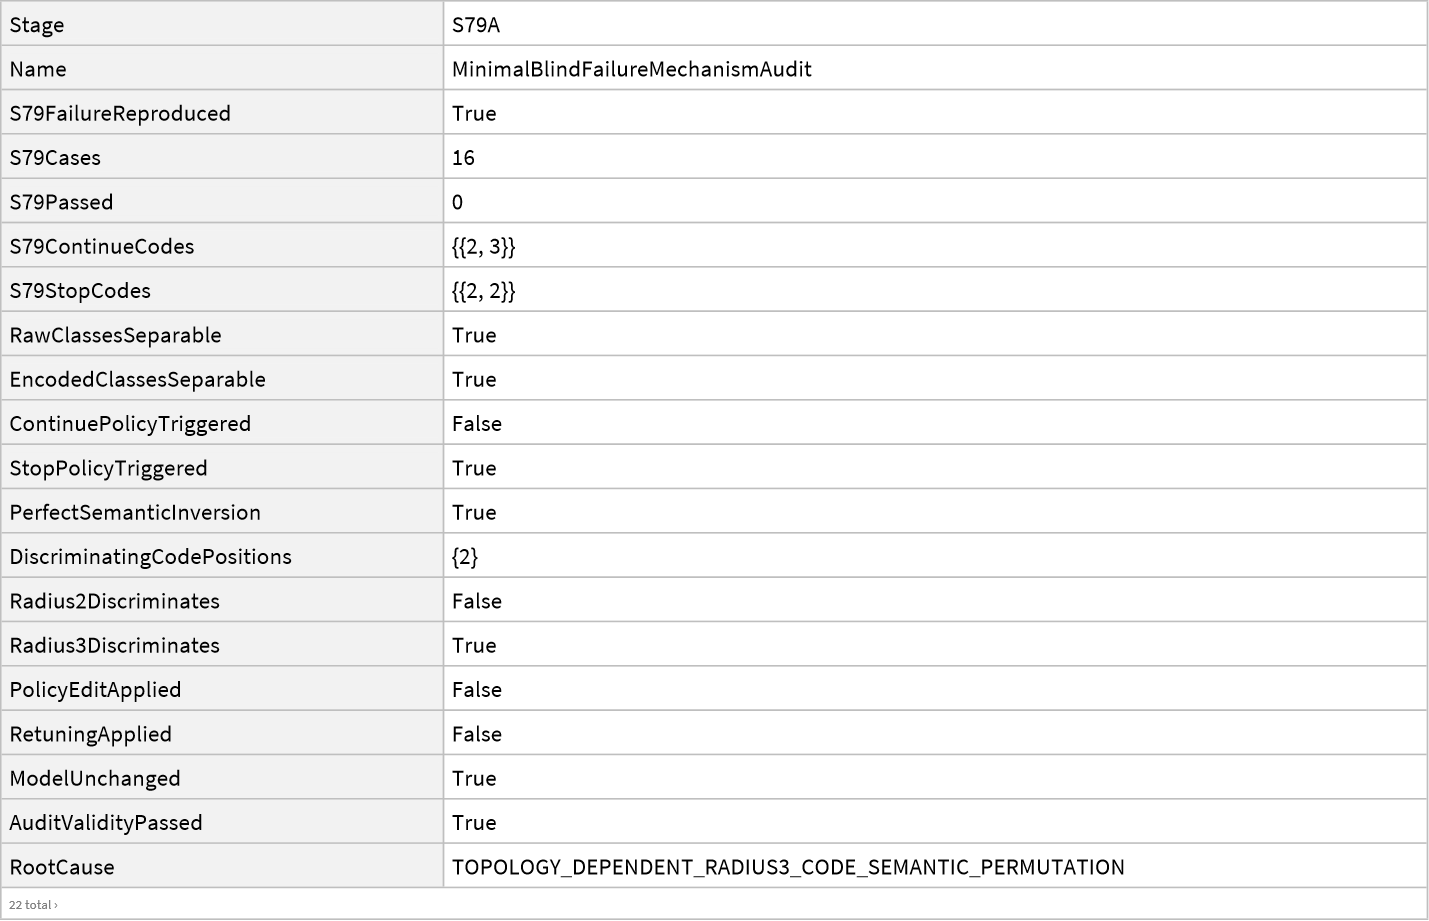

In [55]:
s79ContinueRawHashes79A=RawHashSetByTarget79A[
s79ReproductionRows79A,
"Continue"
];

s79StopRawHashes79A=RawHashSetByTarget79A[
s79ReproductionRows79A,
"Stop"
];

s79RawClassesSeparable79A=SameQ[
Intersection[
s79ContinueRawHashes79A,
s79StopRawHashes79A
],
{}
];

s79EncodedClassesSeparable79A=SameQ[
Intersection[s79ContinueCodes79A,s79StopCodes79A],
{}
];

s79ContinuePolicyTriggered79A=And@@Map[
MemberQ[frozen75D["Policy"],#]&,
s79ContinueCodes79A
];

s79StopPolicyTriggered79A=And@@Map[
MemberQ[frozen75D["Policy"],#]&,
s79StopCodes79A
];

s79PerfectSemanticInversion79A=And[
TrueQ[s79RawClassesSeparable79A],
TrueQ[s79EncodedClassesSeparable79A],
SameQ[s79ContinueCodes79A,{{2,3}}],
SameQ[s79StopCodes79A,{{2,2}}],
SameQ[s79ContinuePolicyTriggered79A,False],
SameQ[s79StopPolicyTriggered79A,True]
];

s79DiscriminatingCodePositions79A=Select[
Range[2],
Intersection[
DeleteDuplicates[s79ContinueCodes79A[[All,#]]],
DeleteDuplicates[s79StopCodes79A[[All,#]]]
]==={}&
];

modelHashAfterAudit79A=Hash[
Normal[frozen75D],
"SHA256",
"HexString"
];

modelUnchanged79A=SameQ[
modelHashAfterAudit79A,
expectedFrozenModelHash79A
];

auditValidityPassed79A=And[
TrueQ[preflightPass79A],
TrueQ[s79FailureReproduced79A],
SameQ[Length[motifAuditRows79A],48],
SameQ[
Count[
motifAuditRows79A,
row_/;TrueQ[row["TerminatedNaturally"]]
],
48
],
SameQ[
Count[
motifAuditRows79A,
row_/;TrueQ[row["HitSafetyCap"]]
],
0
],
TrueQ[modelUnchanged79A]
];

rootCause79A=Which[
!TrueQ[auditValidityPassed79A],
"INVALID_AUDIT",
TrueQ[s79PerfectSemanticInversion79A]&&
SameQ[s79DiscriminatingCodePositions79A,{2}],
"TOPOLOGY_DEPENDENT_RADIUS3_CODE_SEMANTIC_PERMUTATION",
TrueQ[s79PerfectSemanticInversion79A],
"TOPOLOGY_DEPENDENT_CODE_SEMANTIC_PERMUTATION",
!TrueQ[s79RawClassesSeparable79A],
"RAW_STATE_SEMANTIC_COLLISION",
!TrueQ[s79EncodedClassesSeparable79A],
"ENCODER_CODE_COLLISION",
True,
"UNRESOLVED_REPRESENTATION_POLICY_MISMATCH"
];

auditPayload79A=<|
"Stage"->"S79A",
"Name"->"MinimalBlindFailureMechanismAudit",
"ExpectedS79BlindResultHash"->
expectedS79BlindResultHash79A,
"MinimalKernelHash"->minimalKernelHash79A,
"S79FailureReproduced"->s79FailureReproduced79A,
"S79Cases"->Length[s79ReproductionRows79A],
"S79Passed"->Count[
s79ReproductionRows79A,
row_/;TrueQ[row["Correct"]]
],
"S79ContinueCodes"->s79ContinueCodes79A,
"S79StopCodes"->s79StopCodes79A,
"RawClassesSeparable"->s79RawClassesSeparable79A,
"EncodedClassesSeparable"->
s79EncodedClassesSeparable79A,
"ContinuePolicyTriggered"->
s79ContinuePolicyTriggered79A,
"StopPolicyTriggered"->s79StopPolicyTriggered79A,
"PerfectSemanticInversion"->
s79PerfectSemanticInversion79A,
"DiscriminatingCodePositions"->
s79DiscriminatingCodePositions79A,
"Radius2Discriminates"->MemberQ[
s79DiscriminatingCodePositions79A,
1
],
"Radius3Discriminates"->MemberQ[
s79DiscriminatingCodePositions79A,
2
],
"MotifSummary"->motifSummary79A,
"PolicyEditApplied"->False,
"RetuningApplied"->False,
"CandidateSearchRun"->False,
"ModelUnchanged"->modelUnchanged79A,
"AuditValidityPassed"->auditValidityPassed79A,
"RootCause"->rootCause79A
|>;

auditResultHash79A=Hash[
Normal[auditPayload79A],
"SHA256",
"HexString"
];

cert79A=Join[
auditPayload79A,
<|
"AuditOnly"->True,
"StandaloneMinimalKernel"->True,
"HistoricalTestsIncluded"->False,
"S79BlindResultChanged"->False,
"PolicySwapDiagnosticOnly"->True,
"PolicySwapApplied"->False,
"AuditResultHash"->auditResultHash79A,
"SuggestedNextStage"->If[
SameQ[
rootCause79A,
"TOPOLOGY_DEPENDENT_RADIUS3_CODE_SEMANTIC_PERMUTATION"
],
"S79B_CanonicalSemanticAnchoringDesignWithoutBlindRetuning",
"ExtendS79A_AuditWithoutChangingFrozenModel"
]
|>
];

Dataset[{KeyTake[
cert79A,
{
"Stage",
"Name",
"S79FailureReproduced",
"S79Cases",
"S79Passed",
"S79ContinueCodes",
"S79StopCodes",
"RawClassesSeparable",
"EncodedClassesSeparable",
"ContinuePolicyTriggered",
"StopPolicyTriggered",
"PerfectSemanticInversion",
"DiscriminatingCodePositions",
"Radius2Discriminates",
"Radius3Discriminates",
"PolicyEditApplied",
"RetuningApplied",
"ModelUnchanged",
"AuditValidityPassed",
"RootCause",
"AuditResultHash",
"SuggestedNextStage"
}
]}]
